# 🌾 Crop Recommendation — Exploratory Data Analysis

**Dataset:** Crop Recommendation Dataset  
**Source:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset  
**Type:** Supervised Learning — Multi-class Classification  

| Feature | Description |
|---------|-------------|
| N | Nitrogen content in soil |
| P | Phosphorus content in soil |
| K | Potassium content in soil |
| temperature | Temperature in °C |
| humidity | Relative humidity in % |
| ph | pH value of the soil |
| rainfall | Rainfall in mm |
| label | Crop to be grown **(Target Variable)** |

In [1]:
# ── CELL 1 — Import Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# ── CELL 2 — Load Dataset (Colab Files Tab) ────────────────────────────────
# Make sure Crop_recommendation.csv is uploaded in the Colab Files panel (left sidebar)

df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded!
Shape: 2200 rows × 8 columns


In [3]:
# ── CELL 3 — First Look ────────────────────────────────────────────────────
print('First 5 rows:')
df.head()

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# ── CELL 4 — Dataset Info ──────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
# ── CELL 5 — Missing Values & Duplicates ──────────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found ✅')

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Duplicate Rows ===
Duplicate rows: 0
No duplicates found ✅


In [6]:
# ── CELL 6 — Statistical Summary ──────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='YlGn')

,count,mean,std,min,25%,50%,75%,max
N,2200.000000,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.000000,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.000000,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.000000,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.000000,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.000000,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.000000,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [7]:
# ── CELL 7 — Crop Distribution ────────────────────────────────────────────
crop_counts = df['label'].value_counts()
print(f'Unique crops: {df["label"].nunique()}')
print(crop_counts)

Unique crops: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


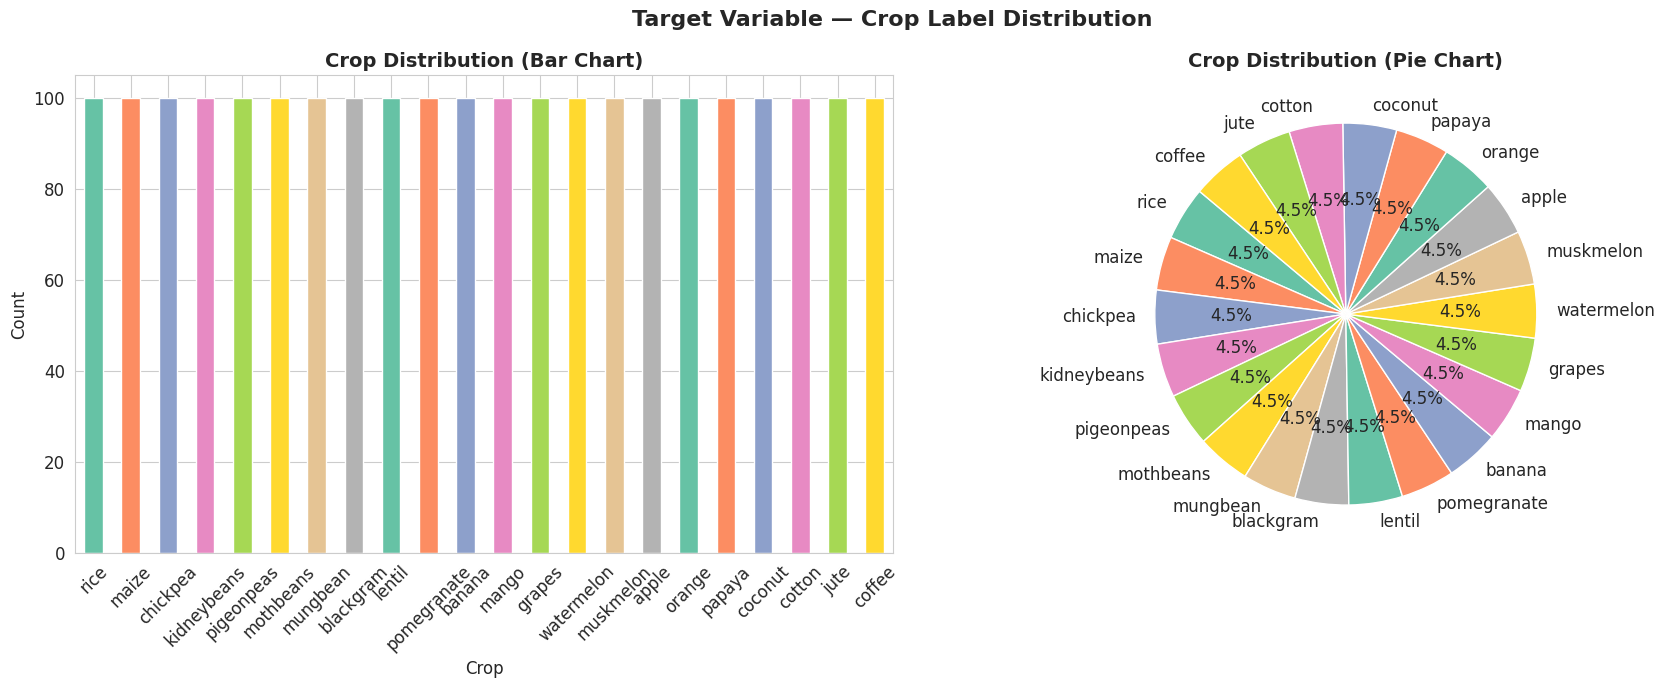

In [8]:
# ── CELL 8 — Crop Distribution Plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

crop_counts.plot(kind='bar', ax=axes[0],
                 color=sns.color_palette('Set2', len(crop_counts)))
axes[0].set_title('Crop Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Crop')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(crop_counts, labels=crop_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(crop_counts)), startangle=140)
axes[1].set_title('Crop Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Crop Label Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

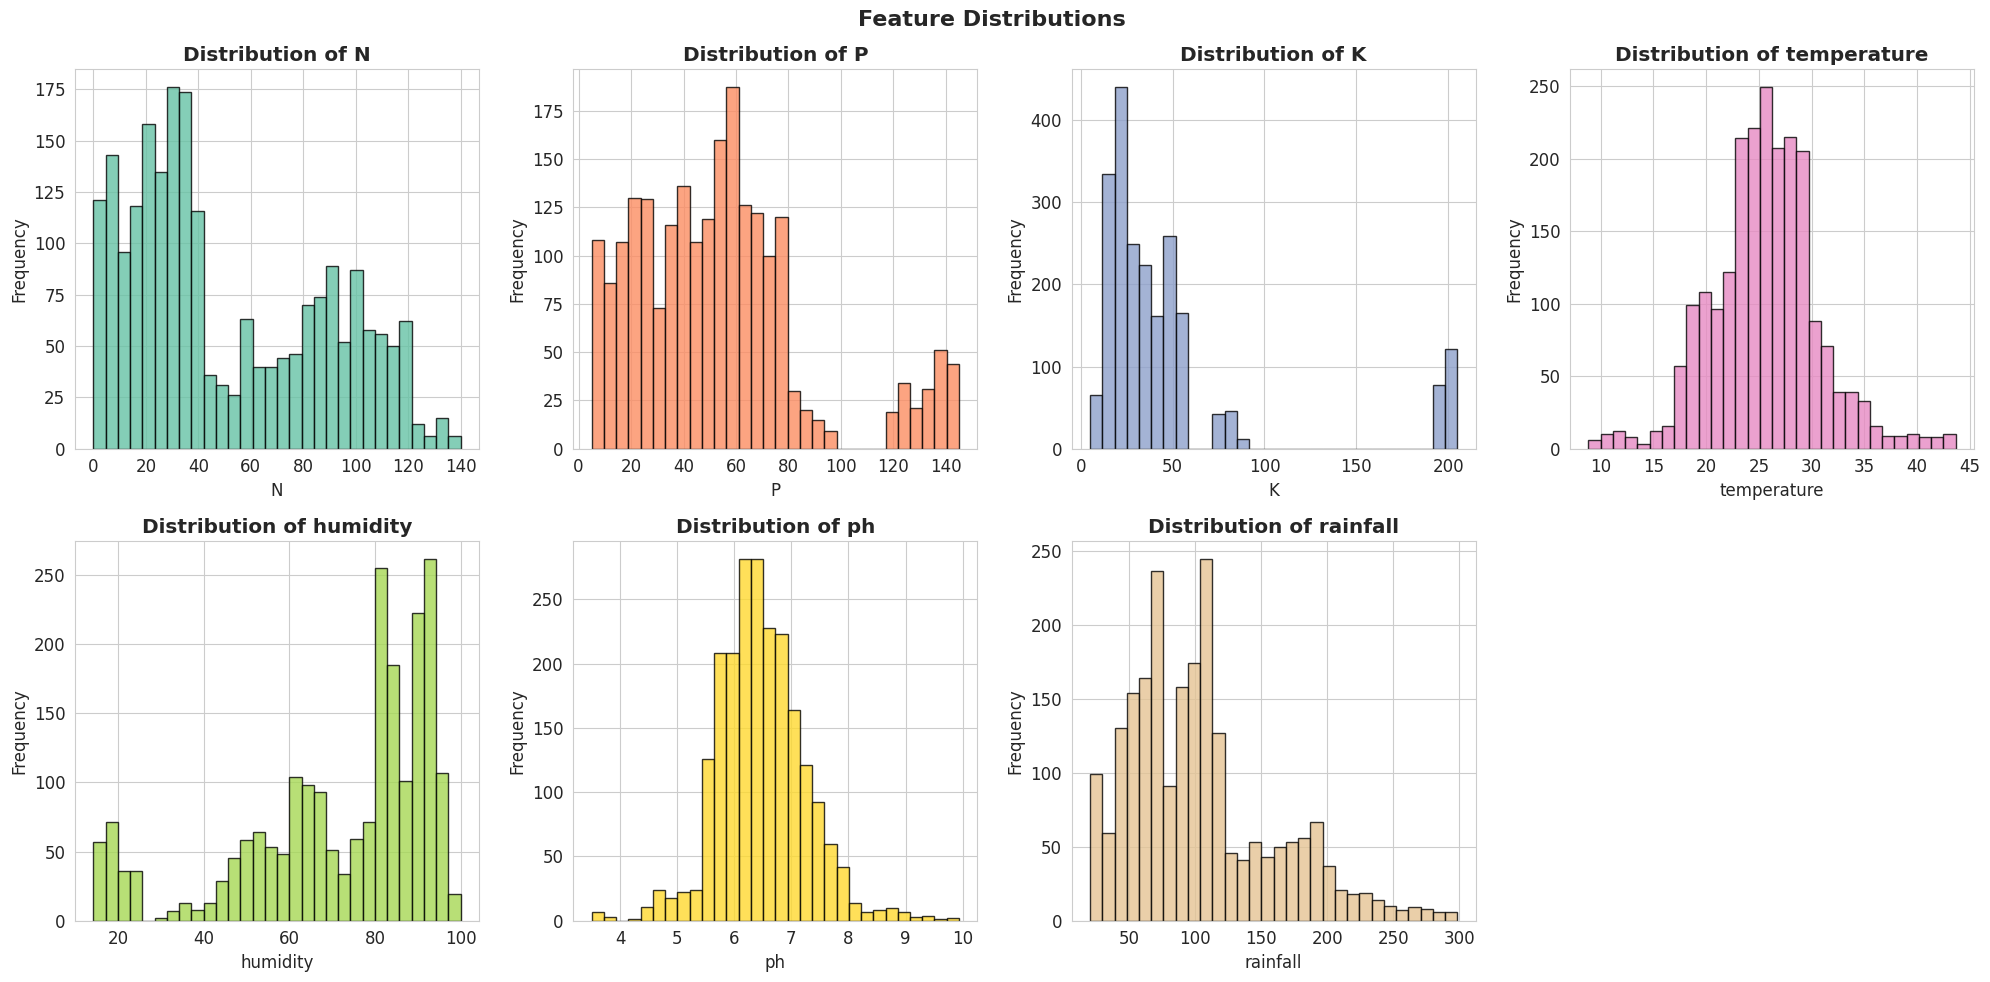

In [9]:
# ── CELL 9 — Feature Histograms ───────────────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30,
                 color=sns.color_palette('Set2')[i % 8],
                 edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

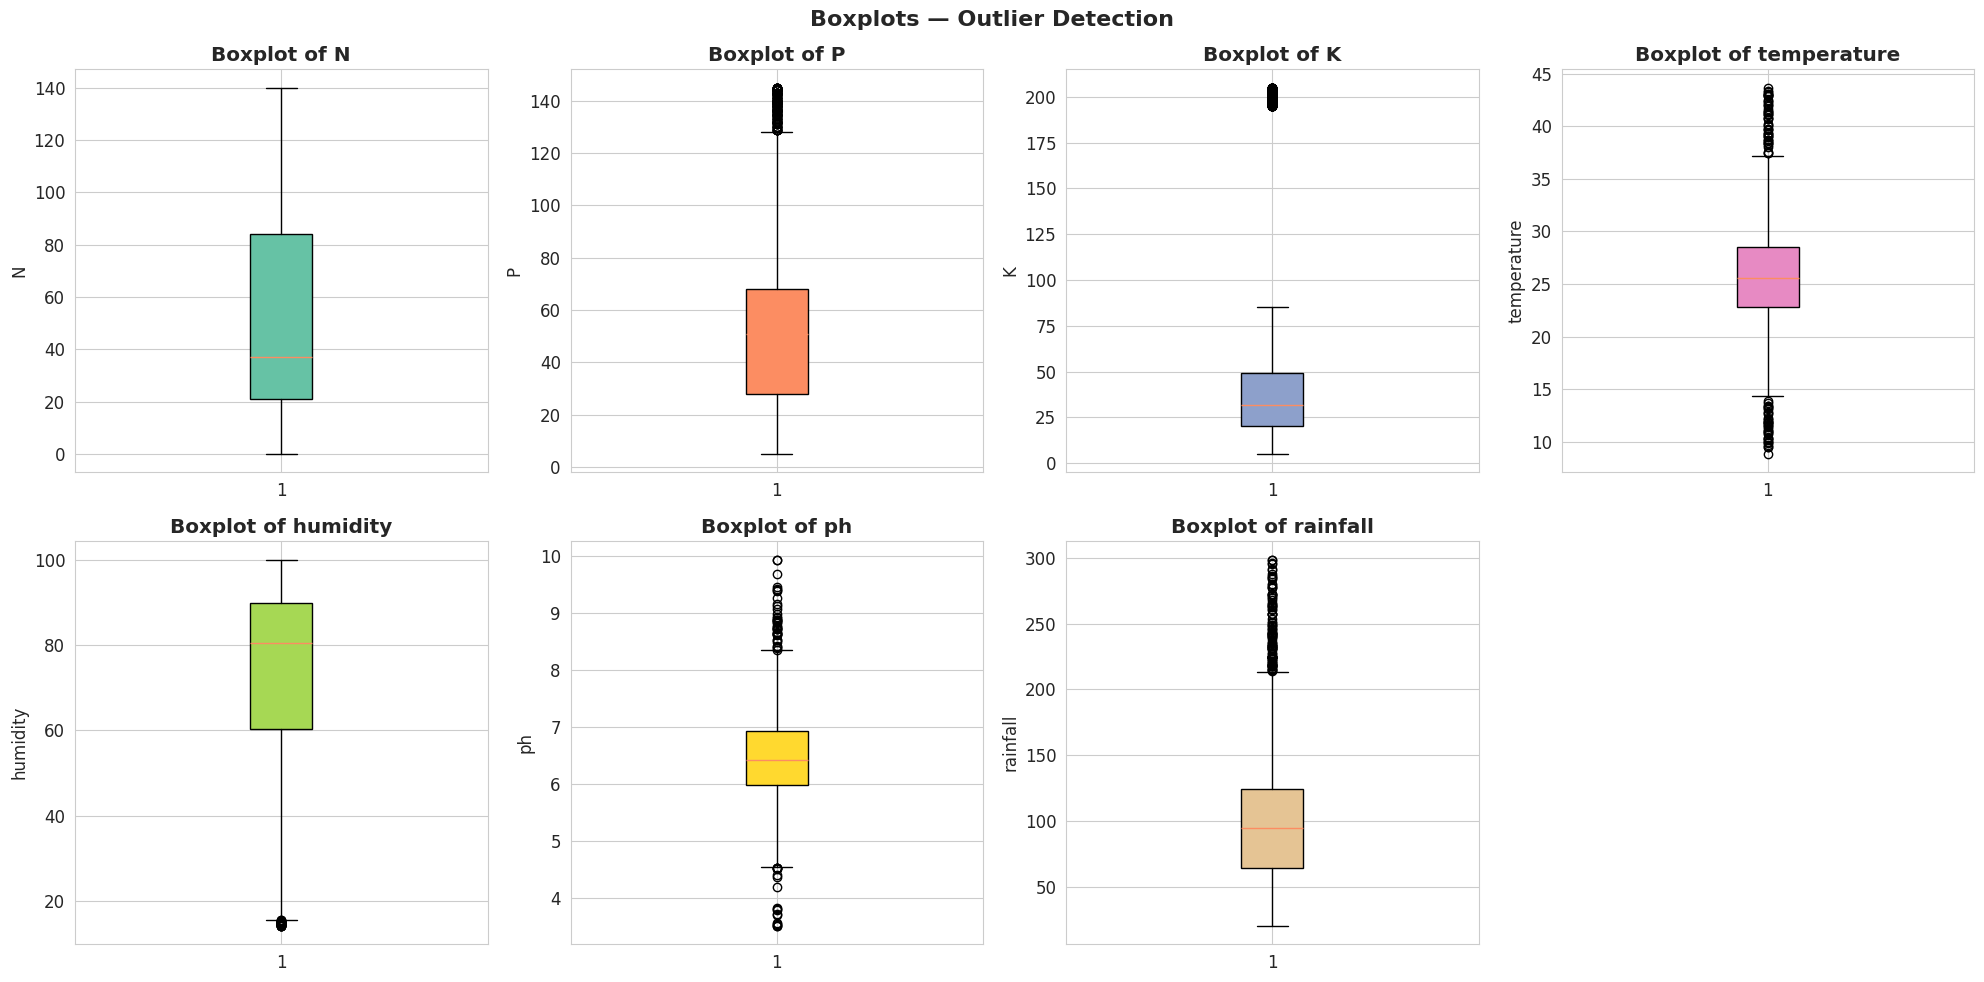

In [10]:
# ── CELL 10 — Boxplots (Outlier Detection) ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('Set2')[i % 8]))
    axes[i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── CELL 11 — IQR Outlier Count ───────────────────────────────────────────
print('=== Outlier Count per Feature (IQR Method) ===')
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'{col:15s}: {outliers} outliers  (valid range: {lower:.2f} – {upper:.2f})')

=== Outlier Count per Feature (IQR Method) ===
N              : 0 outliers  (valid range: -73.88 – 179.12)
P              : 138 outliers  (valid range: -32.00 – 128.00)
K              : 200 outliers  (valid range: -23.50 – 92.50)
temperature    : 86 outliers  (valid range: 14.08 – 37.25)
humidity       : 30 outliers  (valid range: 15.73 – 134.48)
ph             : 57 outliers  (valid range: 4.54 – 8.35)
rainfall       : 100 outliers  (valid range: -25.02 – 213.84)


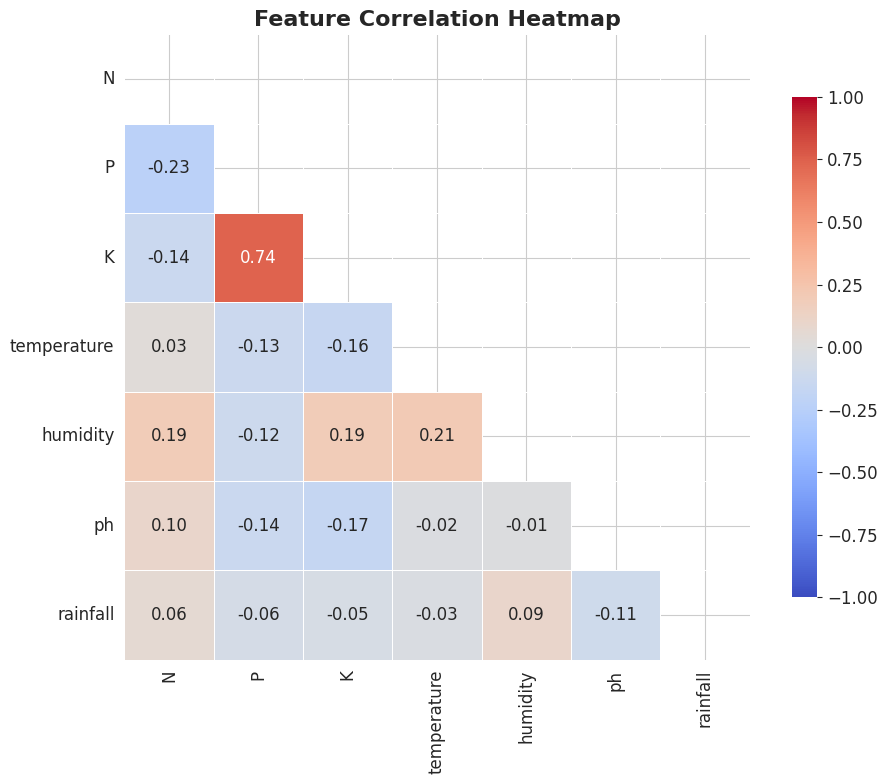

In [12]:
# ── CELL 12 — Correlation Heatmap ─────────────────────────────────────────
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ── CELL 13 — Mean Feature Values per Crop ────────────────────────────────
crop_means = df.groupby('label')[features].mean().round(2)
print('Mean feature values per crop:')
crop_means.style.background_gradient(cmap='YlGn', axis=0)

Mean feature values per crop:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.800000,134.220000,199.890000,22.630000,92.330000,5.930000,112.650000
banana,100.230000,82.010000,50.050000,27.380000,80.360000,5.980000,104.630000
blackgram,40.020000,67.470000,19.240000,29.970000,65.120000,7.130000,67.880000
chickpea,40.090000,67.790000,79.920000,18.870000,16.860000,7.340000,80.060000
coconut,21.980000,16.930000,30.590000,27.410000,94.840000,5.980000,175.690000
coffee,101.200000,28.740000,29.940000,25.540000,58.870000,6.790000,158.070000
cotton,117.770000,46.240000,19.560000,23.990000,79.840000,6.910000,80.400000
grapes,23.180000,132.530000,200.110000,23.850000,81.880000,6.030000,69.610000
jute,78.400000,46.860000,39.990000,24.960000,79.640000,6.730000,174.790000


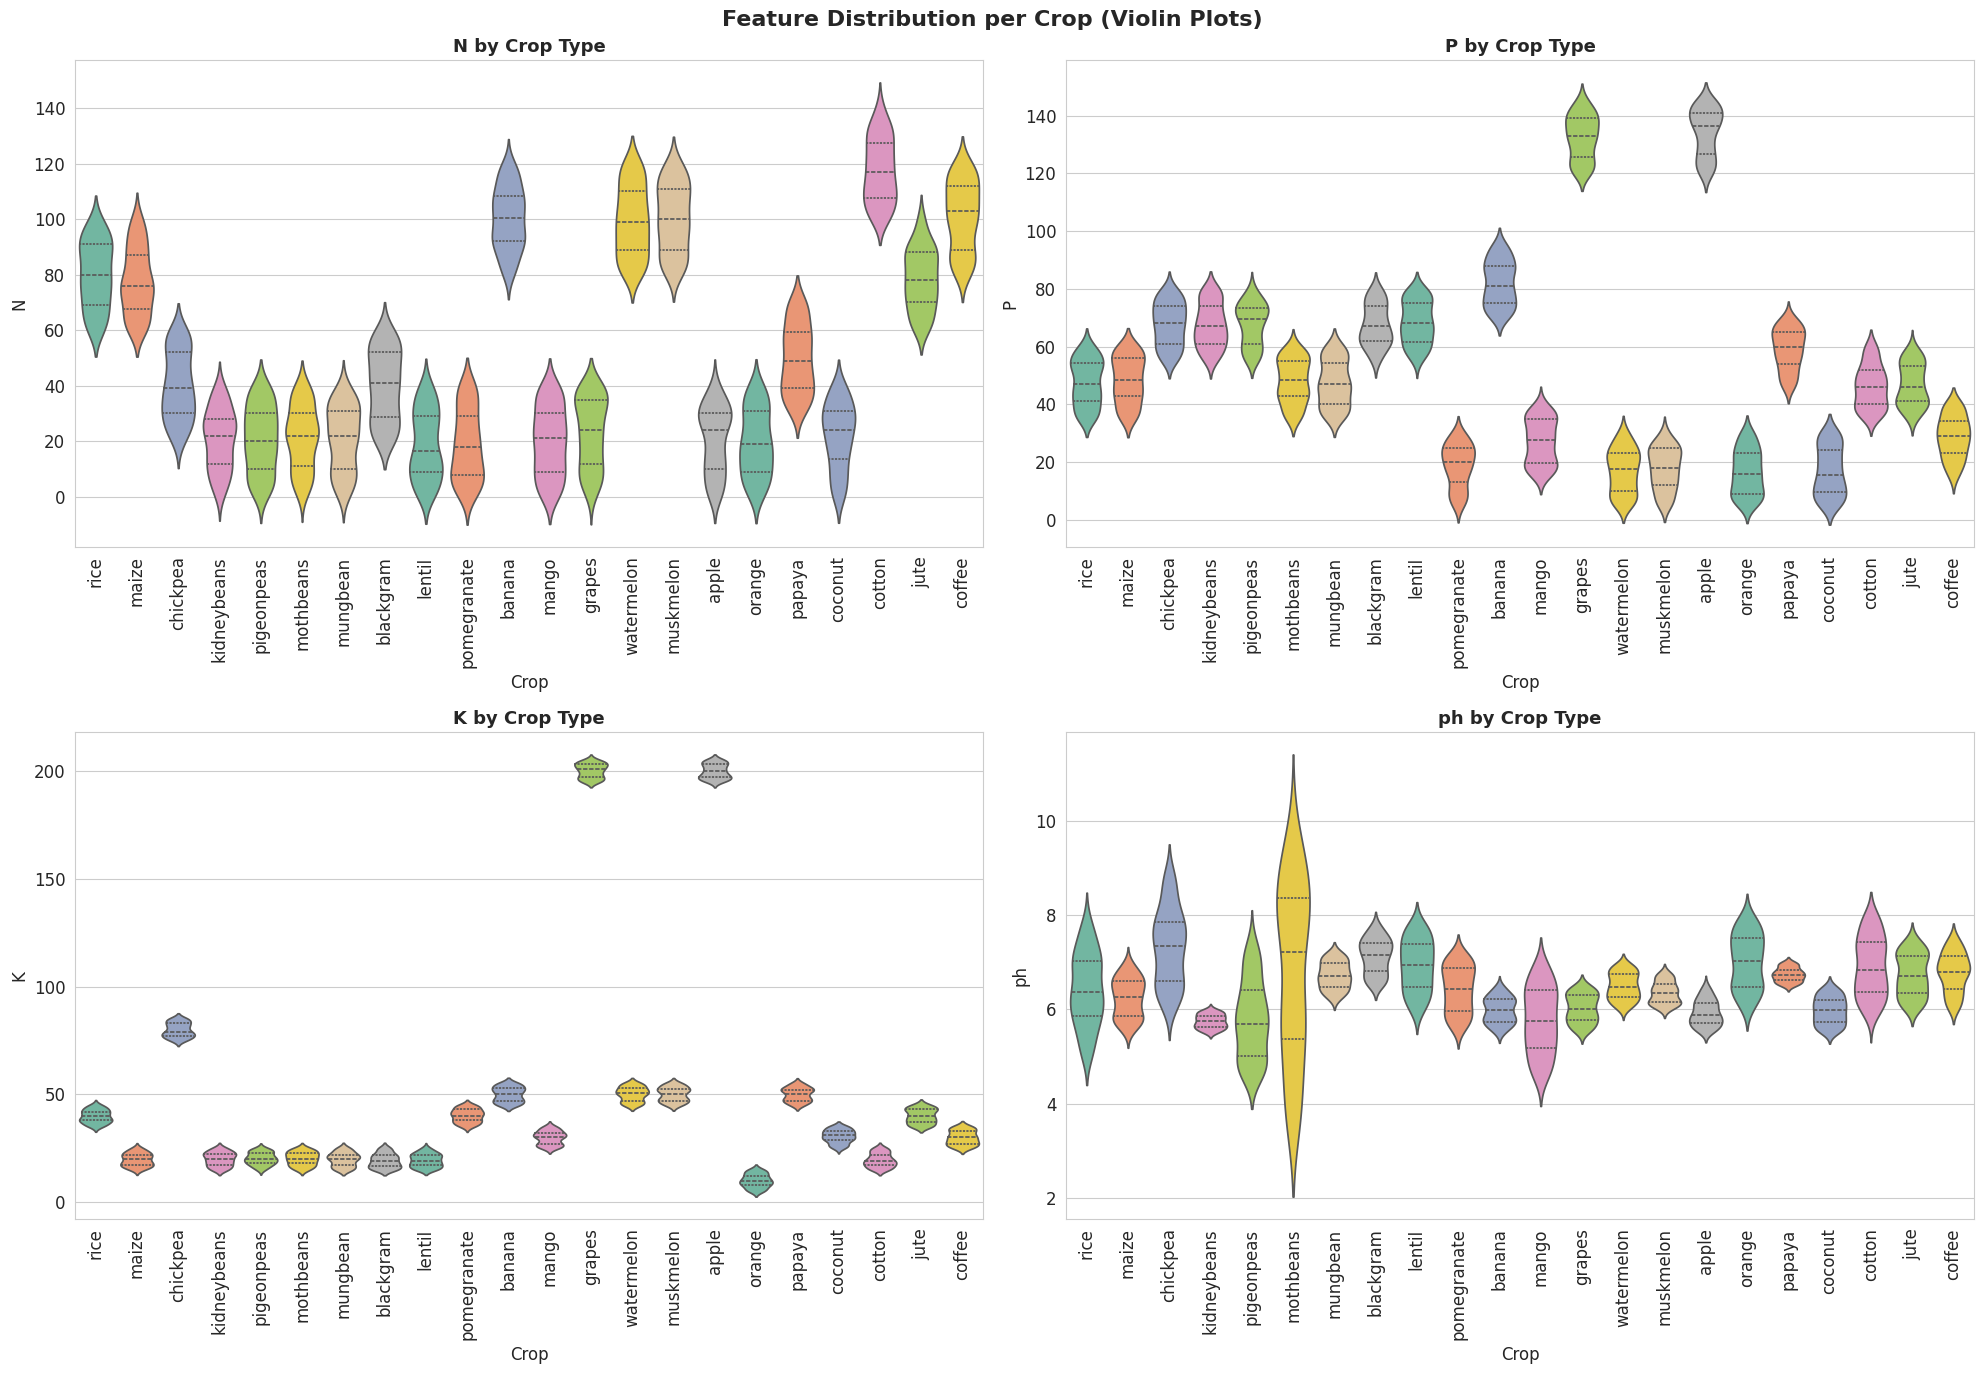

In [14]:
# ── CELL 14 — Violin Plots ────────────────────────────────────────────────
key_features = ['N', 'P', 'K', 'ph']

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.violinplot(data=df, x='label', y=col, ax=axes[i],
                   palette='Set2', inner='quartile')
    axes[i].set_title(f'{col} by Crop Type', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=90)

plt.suptitle('Feature Distribution per Crop (Violin Plots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

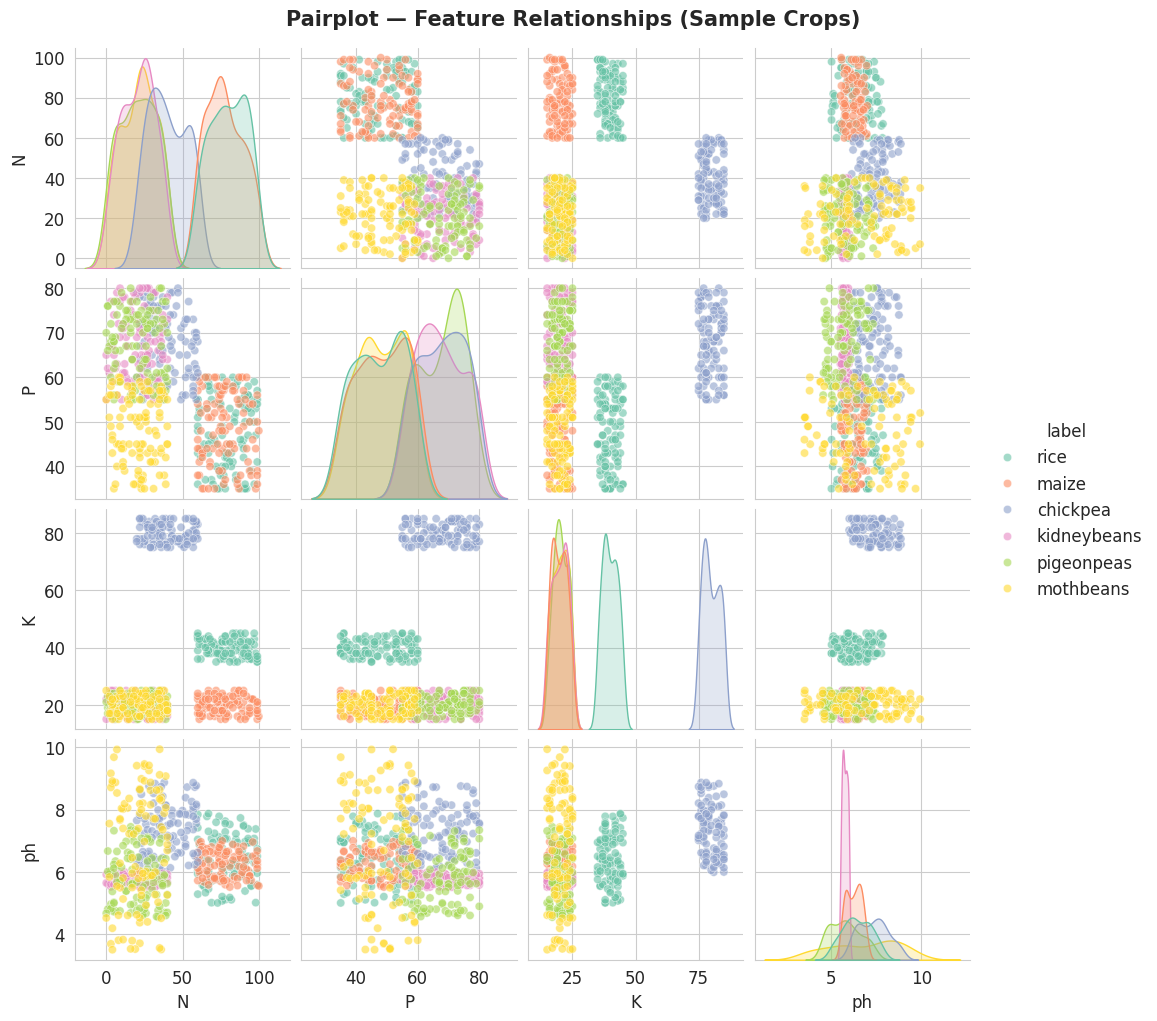

In [15]:
# ── CELL 15 — Pairplot ────────────────────────────────────────────────────
sample_crops = df['label'].unique()[:6]
df_sample = df[df['label'].isin(sample_crops)]

g = sns.pairplot(df_sample[['N', 'P', 'K', 'ph', 'label']],
                 hue='label', palette='Set2',
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot — Feature Relationships (Sample Crops)',
               y=1.02, fontsize=15, fontweight='bold')
plt.show()

In [16]:
# ── CELL 16 — Skewness & Kurtosis ─────────────────────────────────────────
skew_kurt = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurtosis()
}).round(4)

print('=== Skewness & Kurtosis ===')
print(skew_kurt)
print('\nNote: |Skewness| > 1 → significant skew')
print('Note: Kurtosis > 3  → heavy tails')

=== Skewness & Kurtosis ===
             Skewness  Kurtosis
N              0.5097   -1.0582
P              1.0108    0.8603
K              2.3752    4.4494
temperature    0.1849    1.2326
humidity      -1.0917    0.3021
ph             0.2839    1.6556
rainfall       0.9658    0.6071

Note: |Skewness| > 1 → significant skew
Note: Kurtosis > 3  → heavy tails


In [17]:
# ── CELL 17 — EDA Summary ─────────────────────────────────────────────────
print('=' * 55)
print('        EDA SUMMARY — CROP RECOMMENDATION')
print('=' * 55)
print(f'Total samples       : {df.shape[0]}')
print(f'Total features      : {len(features)}')
print(f'Unique crop classes : {df["label"].nunique()}')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum()}')
balance = df['label'].value_counts().std()
print(f'Class balance       : {"Balanced ✅" if balance < 20 else "Slightly Imbalanced ⚠️"}')
print('=' * 55)
print('\n✅ EDA Complete! Proceed to Model Training notebook.')

        EDA SUMMARY — CROP RECOMMENDATION
Total samples       : 2200
Total features      : 7
Unique crop classes : 22
Missing values      : 0
Duplicate rows      : 0
Class balance       : Balanced ✅

✅ EDA Complete! Proceed to Model Training notebook.
